# CIFAR-10 - Fully Connected Network (FCN)

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

I0000 00:00:1774795049.610351    1625 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Input is flattened (32×32×3 → 3072) since FCN ignores spatial structure.  Two hidden fully connected layers (256, 128 neurons) learn features.  ReLU adds non-linearity, softmax outputs class probabilities.

In [2]:
# Creating the FCN model: 
inputs = keras.Input(shape=(32, 32, 3))
x = layers.Flatten()(inputs)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="cifar10_fcn")

I0000 00:00:1774795055.620188    1625 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7535 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:2b:00.0, compute capability: 8.6


CIFAR-10 is loaded and normalized to [0,1] for stable training. Labels are flattened to match sparse loss format. Adam optimizer and cross-entropy are used for efficient classification. Model is trained for 20 epochs with validation split to monitor generalization.

In [4]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data() # load the cifar-10 dataset

y_train = y_train.flatten()
y_test = y_test.flatten()

# Normalize pixel values to [0, 1]
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=["accuracy"],
)

model.summary()

# Training the model
history = model.fit(x_train, y_train, batch_size=32, epochs=20, validation_split=0.2)

/home/jonih/anaconda3/envs/tf_2.21/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Model: "cifar10_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

...

Epoch 1/20


I0000 00:00:1774795237.903976    1741 service.cc:153] XLA service 0x7d49f8030c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774795237.904013    1741 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3080, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1774795237.943016    1741 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774795238.056288    1741 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1774795238.068020    1741 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1215__.13
I0000 00:00:1774795238.972522    1741 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


  26/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1438 - loss: 2.6584

I0000 00:00:1774795240.544803    1741 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3179 - loss: 1.8893 - val_accuracy: 0.3597 - val_loss: 1.7605
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3839 - loss: 1.7124 - val_accuracy: 0.4077 - val_loss: 1.6769
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4153 - loss: 1.6326 - val_accuracy: 0.4286 - val_loss: 1.6042
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4320 - loss: 1.5849 - val_accuracy: 0.4163 - val_loss: 1.6242
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4458 - loss: 1.5444 - val_accuracy: 0.4416 - val_loss: 1.5653
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4578 - loss: 1.5164 - val_accuracy: 0.4566 - val_loss: 1.5452
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4670 - loss: 1.4876 - val_accuracy: 0.4402 - val_loss: 1.5765
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4764 - loss: 1.4663 - val_accurac

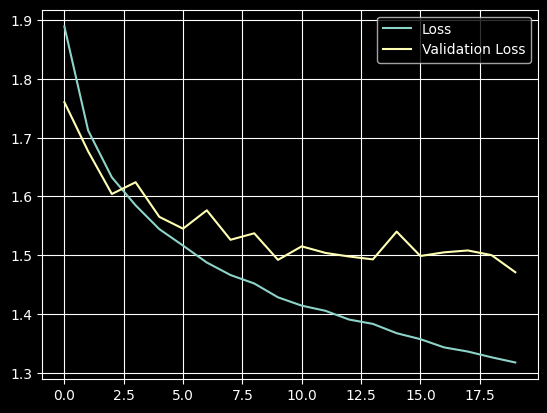

In [5]:
# Plot training and validation loss per epoch
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

Training accuracy improves steadily (~32% → ~53%), showing learning progress. Validation accuracy peaks around ~48–49%, lower than training → slight overfitting. Loss decreases consistently, but validation loss plateaus after ~10 epochs. Model converges, but performance is limited due to lack of spatial feature learning.

In [6]:
# Evaluate final model on unseen test data
test_scores = model.evaluate(x_test, y_test, verbose=2)
print("Test loss:", test_scores[0])
print("Test accuracy:", test_scores[1])

313/313 - 1s - 3ms/step - accuracy: 0.4880 - loss: 1.4491
Test loss: 1.4490556716918945
Test accuracy: 0.4880000054836273


Test accuracy ≈ 48.8%, close to validation accuracy → good generalization. Performance matches expected FCN range (~50%). Limitations due to ignoring spatial structure in images.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


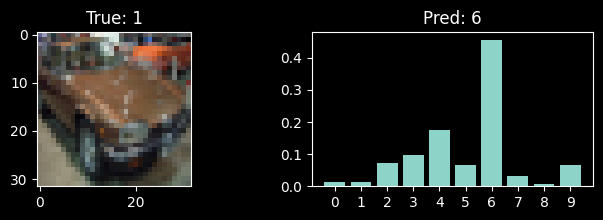

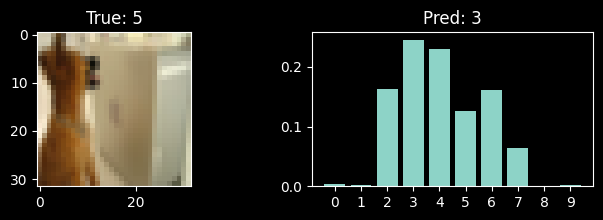

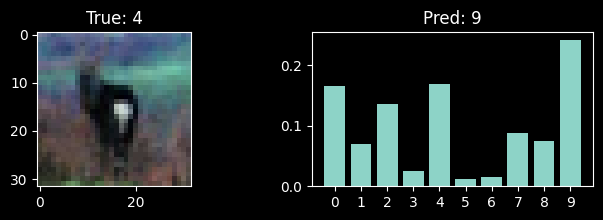

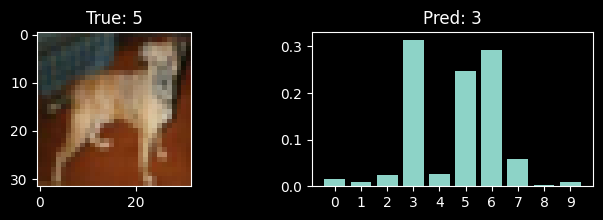

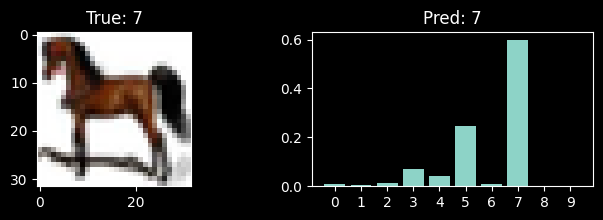

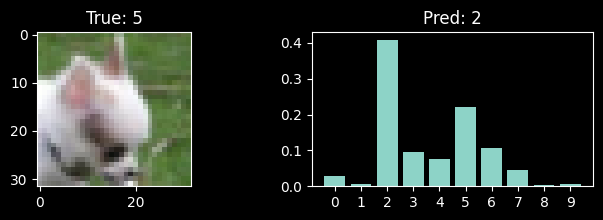

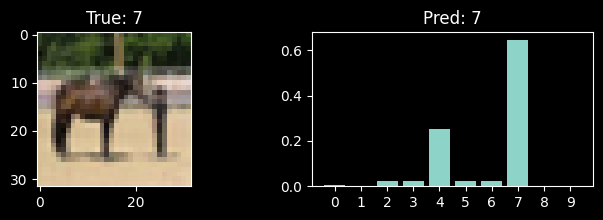

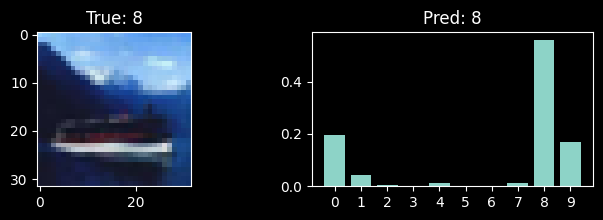

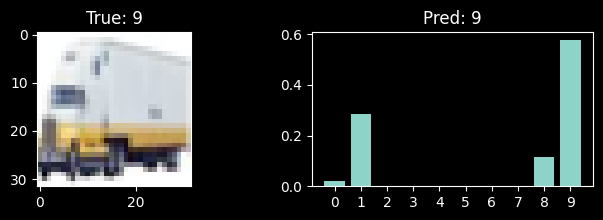

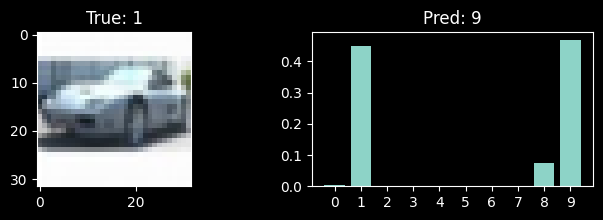

In [7]:
y_pred = model.predict(x_test)
start = 2000

# visualization
for k in range(10):
    plt.figure(figsize=(8, 2))

    plt.subplot(1,2,1)
    plt.imshow(x_test[start+k])
    plt.title(f"True: {y_test[start+k]}")

    plt.subplot(1,2,2)
    plt.bar(range(10), y_pred[start+k].flatten())
    plt.title(f"Pred: {np.argmax(y_pred[start+k])}")

    plt.xticks(range(10))
    plt.show()